In [2]:
import pandas as pd

df = pd.read_csv("/content/final_dataset.csv")
df.head()

,Unnamed: 0,beds,baths,size,zip_code,price
0,0,3,2.5,2590.0,98144,795000.0
1,1,4,2.0,2240.0,98106,915000.0
2,2,4,3.0,2040.0,98107,950000.0
3,3,4,3.0,3800.0,98199,1950000.0
4,4,2,2.0,1042.0,98102,950000.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2016 entries, 0 to 2015
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2016 non-null   int64  
 1   beds        2016 non-null   int64  
 2   baths       2016 non-null   float64
 3   size        2016 non-null   float64
 4   zip_code    2016 non-null   int64  
 5   price       2016 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 94.6 KB


In [4]:
df.describe()

,Unnamed: 0,beds,baths,size,zip_code,price
count,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2.016000e+03
mean,1007.500000,2.857639,2.159970,1735.740575,98123.638889,9.636252e+05
std,582.113391,1.255092,1.002023,920.132591,22.650819,9.440954e+05
min,0.000000,1.000000,0.500000,250.000000,98101.000000,1.590000e+05
25%,503.750000,2.000000,1.500000,1068.750000,98108.000000,6.017500e+05
50%,1007.500000,3.000000,2.000000,1560.000000,98117.000000,8.000000e+05
75%,1511.250000,4.000000,2.500000,2222.500000,98126.000000,1.105250e+06
max,2015.000000,15.000000,9.000000,11010.000000,98199.000000,2.500000e+07


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
beds,0
baths,0
size,0
zip_code,0
price,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(2016, 6)

In [8]:
df.columns

Index(['Unnamed: 0', 'beds', 'baths', 'size', 'zip_code', 'price'], dtype='object')

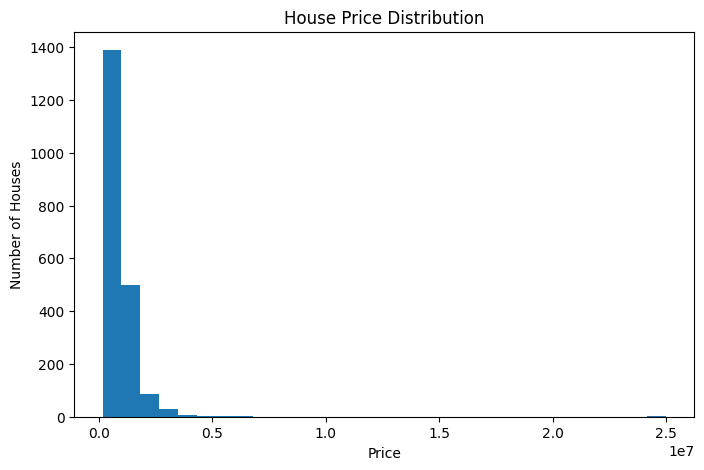

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.title("House Price Distribution")
plt.show()

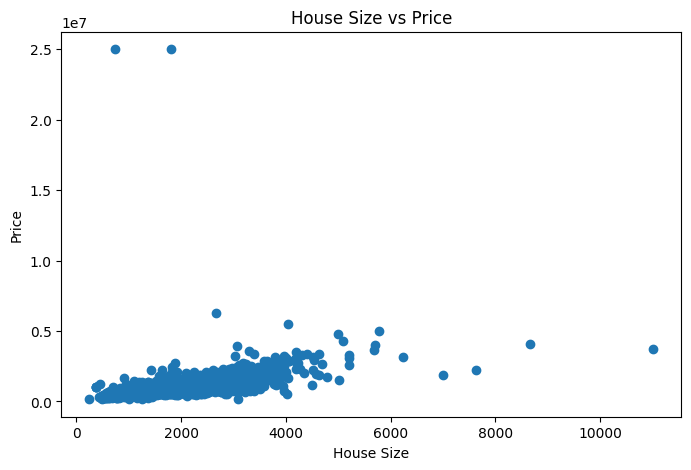

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df["size"], df["price"])
plt.xlabel("House Size")
plt.ylabel("Price")
plt.title("House Size vs Price")
plt.show()

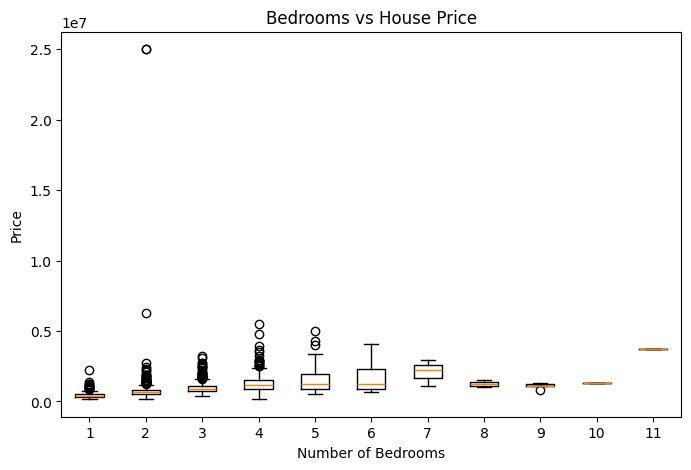

In [11]:
plt.figure(figsize=(8,5))
plt.boxplot([df[df["beds"] == b]["price"].dropna() for b in sorted(df["beds"].dropna().unique())])
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")
plt.title("Bedrooms vs House Price")
plt.show()

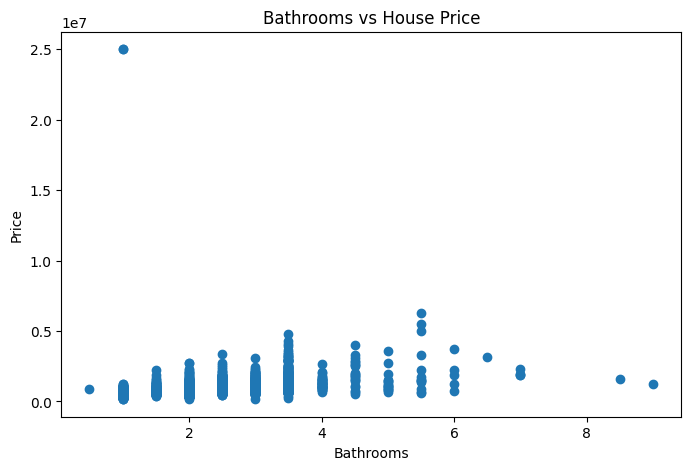

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(df["baths"], df["price"])
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.title("Bathrooms vs House Price")
plt.show()

In [13]:
corr = df[["beds", "baths", "size", "price"]].corr()
corr

,beds,baths,size,price
beds,1.000000,0.652853,0.771929,0.293516
baths,0.652853,1.000000,0.667655,0.317325
size,0.771929,0.667655,1.000000,0.444140
price,0.293516,0.317325,0.444140,1.000000


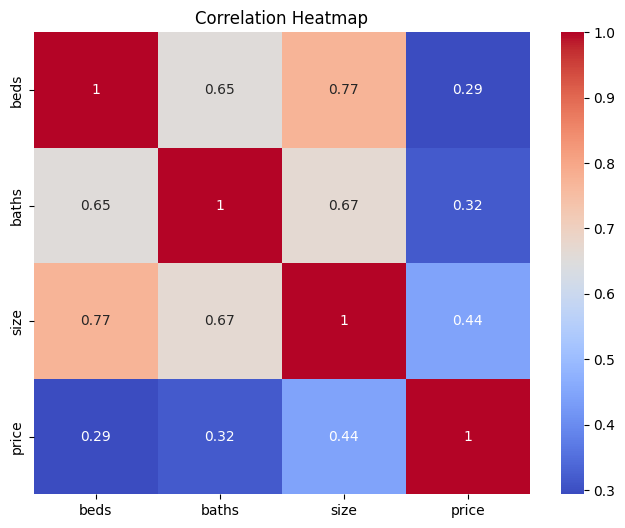

In [14]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
df.groupby("beds")["price"].mean()

,price
beds,
1,4.704662e+05
2,8.224089e+05
3,9.472505e+05
4,1.268430e+06
5,1.532354e+06
6,1.728937e+06
7,2.090000e+06
8,1.252500e+06
9,1.115480e+06


In [16]:
df.groupby("baths")["price"].mean()

,price
baths,
0.5,8.927000e+05
1.0,6.444498e+05
1.5,8.016268e+05
2.0,8.679246e+05
2.5,1.041903e+06
3.0,1.131191e+06
3.5,1.584810e+06
4.0,1.310080e+06
4.5,1.993048e+06


In [17]:
df.nlargest(10, "price")[["beds", "baths", "size", "price"]]

,beds,baths,size,price
1359,2,1.0,730.0,25000000.0
1700,2,1.0,1800.0,25000000.0
637,2,5.5,2659.0,6250000.0
61,4,5.5,4040.0,5495000.0
805,5,5.5,5770.0,5000000.0
1998,4,3.5,4990.0,4815000.0
964,5,3.5,5090.0,4325000.0
74,6,3.5,8660.0,4100000.0
1945,5,4.5,5704.0,4000000.0
557,4,3.5,3060.0,3931000.0


In [18]:
df.nsmallest(10, "price")[["beds", "baths", "size", "price"]]

,beds,baths,size,price
770,1,1.0,250.0,159000.0
355,2,1.0,1011.0,159488.0
1521,1,2.0,1250.0,160000.0
674,1,1.0,492.0,205000.0
777,4,3.0,3090.0,210000.0
463,2,3.5,1155.0,219700.0
1780,1,1.0,482.0,220000.0
1902,1,1.0,557.0,222000.0
1233,1,1.0,534.0,223000.0
410,1,1.0,813.0,240000.0


In [19]:
print("Average House Price:", df["price"].mean())
print("Maximum House Price:", df["price"].max())
print("Minimum House Price:", df["price"].min())
print("Average House Size:", df["size"].mean())
print("Average Bedrooms:", df["beds"].mean())
print("Average Bathrooms:", df["baths"].mean())

Average House Price: 963625.224702381
Maximum House Price: 25000000.0
Minimum House Price: 159000.0
Average House Size: 1735.7405753968253
Average Bedrooms: 2.857638888888889
Average Bathrooms: 2.159970238095238


In [20]:
print("📊 HOUSE PRICE ANALYSIS INSIGHTS")
print("--------------------------------")

print("1. Average House Price:", round(df["price"].mean(), 2))
print("2. Minimum House Price:", round(df["price"].min(), 2))
print("3. Maximum House Price:", round(df["price"].max(), 2))
print("4. Average House Size:", round(df["size"].mean(), 2))
print("5. Average Bedrooms:", round(df["beds"].mean(), 2))
print("6. Average Bathrooms:", round(df["baths"].mean(), 2))

print("\nCorrelation with Price:")
print(df[["beds", "baths", "size", "price"]].corr()["price"].sort_values(ascending=False))

📊 HOUSE PRICE ANALYSIS INSIGHTS
--------------------------------
1. Average House Price: 963625.22
2. Minimum House Price: 159000.0
3. Maximum House Price: 25000000.0
4. Average House Size: 1735.74
5. Average Bedrooms: 2.86
6. Average Bathrooms: 2.16

Correlation with Price:
price    1.000000
size     0.444140
baths    0.317325
beds     0.293516
Name: price, dtype: float64


In [21]:
correlation = df["size"].corr(df["price"])

print("Correlation between House Size and Price:", round(correlation, 2))

if correlation > 0:
    print("Insight: House size आणि price मध्ये positive relationship आहे.")
else:
    print("Insight: House size आणि price मध्ये negative relationship आहे.")

Correlation between House Size and Price: 0.44
Insight: House size आणि price मध्ये positive relationship आहे.


In [22]:
print("========== FINAL CONCLUSION ==========")

print("• The dataset contains house information such as beds, baths, size, zip code and price.")
print("• House size is an important factor related to house price.")
print("• The analysis shows how bedroom and bathroom counts vary with house prices.")
print("• Larger houses generally tend to have higher prices.")
print("• Correlation analysis helps identify the relationship between numerical features and price.")
print("• Data visualization makes the house price patterns easier to understand.")

========== FINAL CONCLUSION ==========
• The dataset contains house information such as beds, baths, size, zip code and price.
• House size is an important factor related to house price.
• The analysis shows how bedroom and bathroom counts vary with house prices.
• Larger houses generally tend to have higher prices.
• Correlation analysis helps identify the relationship between numerical features and price.
• Data visualization makes the house price patterns easier to understand.


In [23]:
df.to_csv("house_price_analysis.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [24]:
from google.colab import files

files.download("house_price_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>